## 1 import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# split data into train & test
from sklearn.model_selection import train_test_split
# import logistic regression & model evaluation
from sklearn.linear_model import LogisticRegression

# Disable Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. READ DATASET

In [2]:
churn_df = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/Telco_Customer_Churn.csv")

In [3]:
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
churn_df.shape

(7043, 21)

## Data Descriptions

* customerID - Unique identifier for each customer
* gender - Gender of the customer
* SeniorCitizen - Whether the customer is a senior citizen (Yes/No)
* PartnerDependents - Whether the customer has a partner and dependents (Yes/No)
* tenure - Number of months the customer has been using telecom services
* PhoneService - Whether the customer has phone service (Yes/No)
* MultipleLines - Whether the customer has multiple lines (Yes/No/NoPhone Services)
* InternetService - The type of internet service the customer using (DSL/Fiber optic etc.)
* OnlineSecurity - Whether the customer has online security (Yes/No)
* OnlineBackup - Whether the customer has online backup service (Yes/No)
* DeviceProtection - Whether the customer has device protection service (Yes/No)
* TechSupport - Whether the customer has tech support services (Yes/No)
* StreamingTV - Whether the customer has streaming TV (Yes/No)
* StreamingMovies - Whether the customer has streaming movies (Yes/No)
* Contract - The type of contract the customer using (Month-to-month, One year etc.)
* PaperlessBilling - Whether the customer has paperless billing (Yes/No)
* PaymentMethod - The method of payment the customer uses (Electronic check, Bank transfer (automatic), Mailed check).
* MonthlyCharges - The monthly charges for the customer
* TotalCharges - The total charges for the customer
* Churn - Whether the customer has churned (Yes/No)

In [6]:
churn_df.info(show_counts=any)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
churn_df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [8]:
# # .......................
# we can see the difference

churn_df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [9]:
churn_df.duplicated().sum()

np.int64(0)

## 3. Handling Missing Values

In [10]:
churn_df['TotalCharges'].replace(' ',np.nan, inplace = True)

In [11]:
churn_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
# show %age of missing values

churn_df.isnull().sum() / churn_df.shape[0] * 100

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.156183
Churn               0.000000
dtype: float64

In [13]:
churn_df['TotalCharges'] = churn_df['TotalCharges'].astype(float)

In [14]:
churn_df.dropna(inplace= True)

## 4. Data Preprocessing

In [15]:
churn_df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [16]:
churn_df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [17]:
churn_df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

## Encoding

There are three different methods are used to convert categorical values to numerical values.

* a. map : map the categoricals values to numerical value.
* b. label encoder : This apply to binary categirical values. It returns values in ordered format.
* c. one-hot encoding : This converts values as new column name and it will filled with 0s & 1.

In [18]:
# map 'yes' to 1 and 'no' to 0
churn_df['Churn'] = churn_df['Churn'].map({'Yes': 1, 'No':0})

In [19]:
# list of binary class

binary_cols = [col for col in churn_df.columns if churn_df[col].dtype == 'object' and churn_df[col].nunique() == 2]

In [20]:
for col in churn_df.columns:
    if churn_df[col].dtype == 'object' and churn_df[col].nunique() ==2:
        print(col)

gender
Partner
Dependents
PhoneService
PaperlessBilling


In [21]:
binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [22]:
from sklearn.preprocessing import LabelEncoder

# To encode/transform categorical column values to numerical values
le = LabelEncoder()

for col in binary_cols:
    # fi() - train label encoder with input samples
    # transform()- apply changes and transform existing dataframe samples
    churn_df[col] = le.fit_transform(churn_df[col])

In [23]:
churn_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50,0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.60,1


In [24]:
for col in churn_df.columns:
    if churn_df[col].dtype == 'object'  and churn_df[col].nunique() > 2:
        print(f"{col}: {churn_df[col].unique()}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [25]:
churn_df['MultipleLines'] = churn_df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
churn_df['OnlineSecurity'] = churn_df['OnlineSecurity'].map({'No internet service': 0, 'No': 0, 'Yes': 1})
churn_df['OnlineBackup'] = churn_df['OnlineBackup'].map({'No internet service': 0, 'No': 0, 'Yes': 1})
churn_df['DeviceProtection'] = churn_df['DeviceProtection'].map({'No internet service': 0, 'No': 0, 'Yes': 1})
churn_df['TechSupport'] = churn_df['TechSupport'].map({'No internet service': 0, 'No': 0, 'Yes': 1})
churn_df['StreamingTV'] = churn_df['StreamingTV'].map({'No internet service': 0, 'No': 0, 'Yes': 1})
churn_df['StreamingMovies'] = churn_df['StreamingMovies'].map({'No internet service': 0, 'No': 0, 'Yes': 1})

In [26]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [27]:
churn_df.drop('customerID', axis = 1, inplace = True)

In [28]:
churn_df['InternetService']

0               DSL
1               DSL
2               DSL
3               DSL
4       Fiber optic
           ...     
7038            DSL
7039    Fiber optic
7040            DSL
7041    Fiber optic
7042    Fiber optic
Name: InternetService, Length: 7032, dtype: object

In [29]:
pd.get_dummies(churn_df['InternetService']).astype('int')

,DSL,Fiber optic,No
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0
...,...,...,...
7038,1,0,0
7039,0,1,0
7040,1,0,0
7041,0,1,0


In [30]:
pd.get_dummies(churn_df['InternetService'], drop_first=True).astype('int')

,Fiber optic,No
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
7038,0,0
7039,1,0
7040,0,0
7041,1,0


In [31]:
churn_data = pd.get_dummies(churn_df).astype('int')

In [32]:
churn_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,1,0,0,0,1,0,0,0,0,1
7039,0,0,1,1,72,1,1,0,1,1,...,0,1,0,0,1,0,0,1,0,0
7040,0,0,1,1,11,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,0,0,0,...,0,1,0,1,0,0,0,0,0,1


## 5. Features & Target

In [33]:
churn_data.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.008883,-0.016328,-0.013093,-0.000807,...,0.007584,-0.011189,0.004745,-0.003251,0.007755,-0.003603,-0.015973,0.001632,0.000844,0.013199
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.142996,-0.038576,0.066663,0.059514,...,-0.108276,0.254923,-0.182519,0.137752,-0.046491,-0.116205,-0.016235,-0.024359,0.171322,-0.152987
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142561,0.143346,0.141849,0.153556,...,-0.001043,0.001235,-0.000286,-0.280202,0.083067,0.247334,0.111406,0.082327,-0.083207,-0.096948
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024307,0.080786,0.023639,0.013900,...,0.051593,-0.164101,0.138383,-0.229715,0.069222,0.201699,0.052369,0.061134,-0.149274,0.056448
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.332399,0.328297,0.361138,0.361520,...,0.013786,0.017930,-0.037529,-0.649346,0.202338,0.563801,0.243822,0.232800,-0.210197,-0.232181
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,0.279530,-0.091676,-0.052133,-0.070076,...,-0.452255,0.290183,0.171817,-0.001243,-0.003142,0.004442,0.008271,-0.006916,0.002747,-0.004463
MultipleLines,-0.008883,0.142996,0.142561,-0.024307,0.332399,0.279530,1.000000,0.098592,0.202228,0.201733,...,-0.200318,0.366420,-0.210794,-0.088558,-0.003594,0.106618,0.075429,0.060319,0.083583,-0.227672
OnlineSecurity,-0.016328,-0.038576,0.143346,0.080786,0.328297,-0.091676,0.098592,1.000000,0.283285,0.274875,...,0.320343,-0.030506,-0.332799,-0.246844,0.100658,0.191698,0.094366,0.115473,-0.112295,-0.079918
OnlineBackup,-0.013093,0.066663,0.141849,0.023639,0.361138,-0.052133,0.202228,0.283285,1.000000,0.303058,...,0.156765,0.165940,-0.380990,-0.164393,0.084113,0.111391,0.086942,0.090455,-0.000364,-0.174075
DeviceProtection,-0.000807,0.059514,0.153556,0.013900,0.361520,-0.070076,0.201733,0.274875,0.303058,1.000000,...,0.145150,0.176356,-0.380151,-0.225988,0.102911,0.165248,0.083047,0.111252,-0.003308,-0.187325


<Axes: >

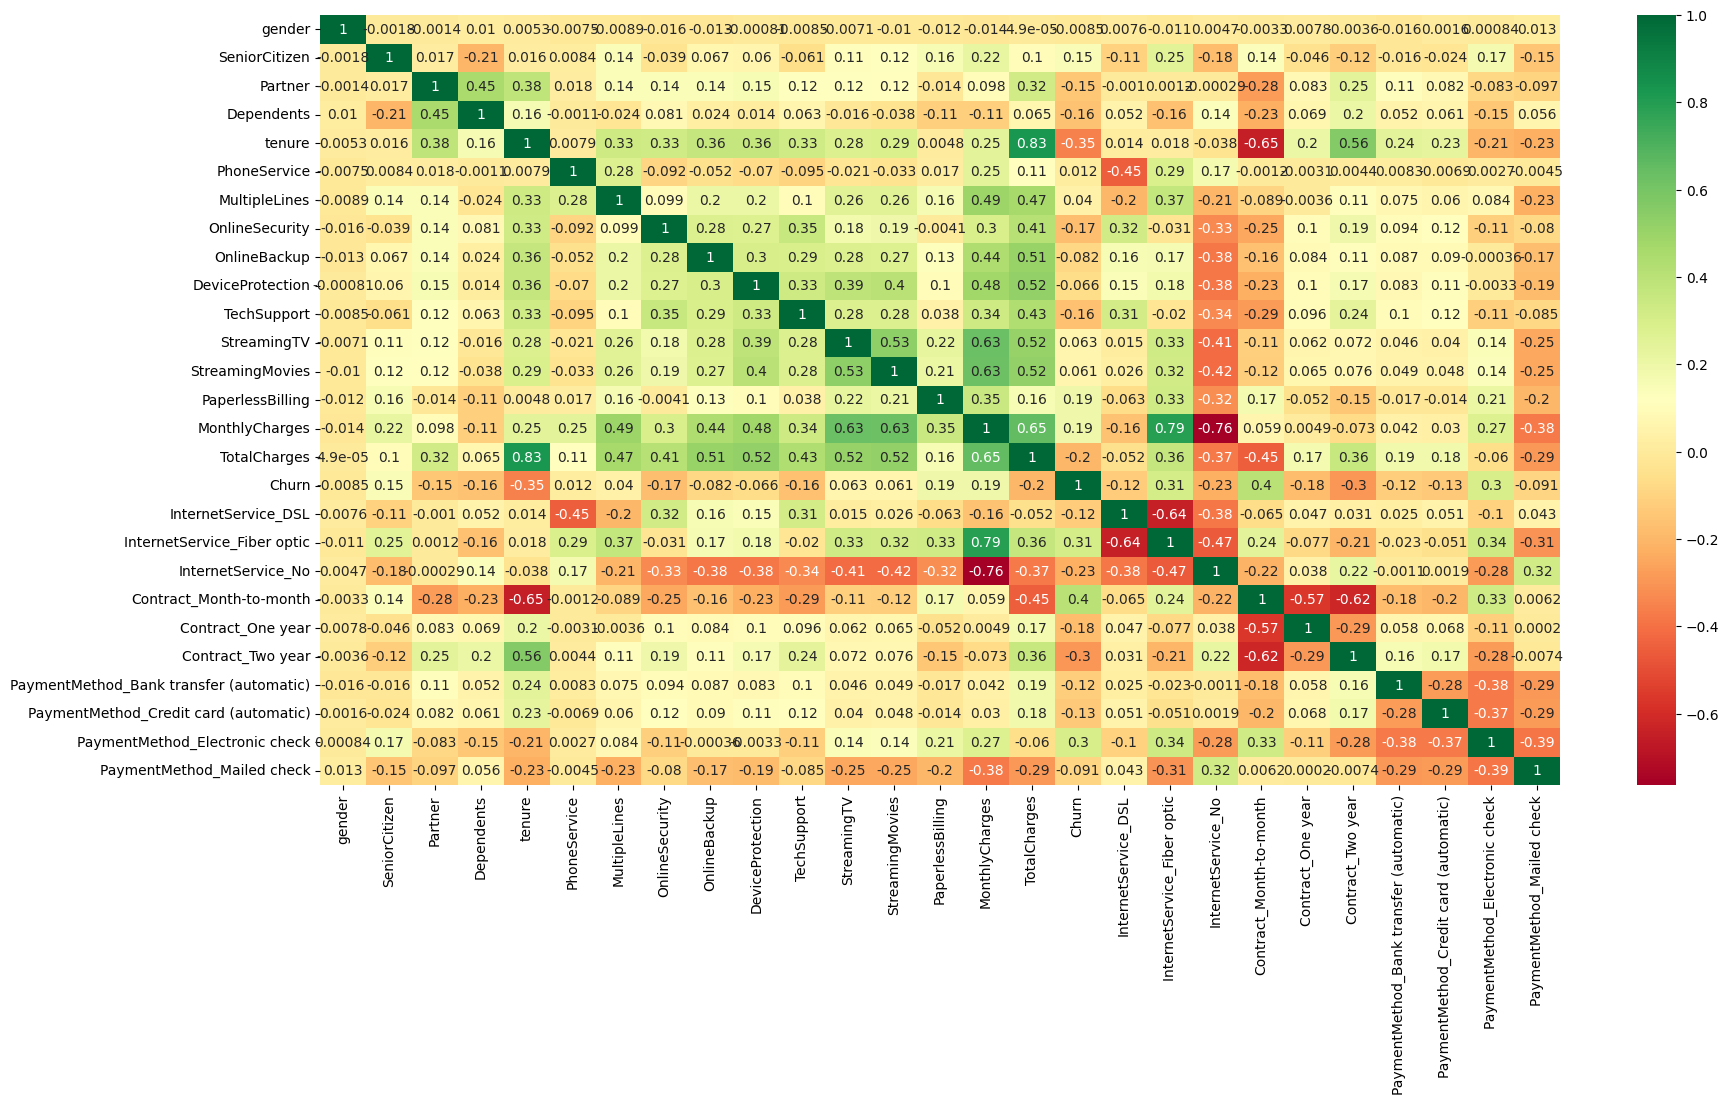

In [34]:
plt.figure(figsize = (20, 10))
sns.heatmap(churn_data.corr(), annot = True, cmap = 'RdYlGn')

* Correlation - It explains relationship between numerical features. It will explain linear relationship and strength of relationship.
* Correlation ranges between (-1, 1)
* if corr is -ve it explain two features are inversly proportional and value will explain how negativly one value is correlated with other.
* if corr is +ve it explain two features are directly proportional and value will explain how positively one value is correlated with other.
* if corr is zero or close to zero, there is no relationship between them.

## 6.Is there any imbalanced class sample

<Axes: xlabel='Churn', ylabel='count'>

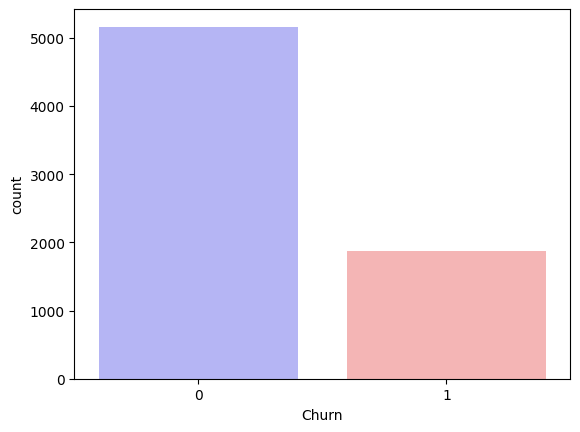

In [35]:
sns.countplot(x = 'Churn', data = churn_data, palette = 'bwr')

In [36]:
churn_data['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [37]:
X = churn_data.drop('Churn', axis = 1)
Y = churn_data['Churn']

##  SMOTE - Synthetic Minority Over-sampling Technique
* This is used for handling imbalanced data by generating synthetic samples for the minority label.

In [38]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
transformed_feature, transformed_label = smote.fit_resample(X, Y)

## 7 Split Data into Train & Test

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(transformed_feature, transformed_label, test_size = 0.2,
                                                    random_state = 2)

## 8. Apply Logistic Regression Model

In [40]:

# solver : 'liblinear', 'lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga'
# max_iter : number of iterations
# C : inverse of regularization
logit_model = LogisticRegression(solver='lbfgs', max_iter = 10000, C = 1)
logit_model.fit(X_train, Y_train)

LogisticRegression(C=1, max_iter=10000)

In [41]:
logit_model.score(X_test, Y_test)

0.8446272991287512

## 9. Classification Metrics
Accuracy, Confusion Matrix, Precision, Recall, F1-Score

In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [43]:
y_pred = logit_model.predict(X_test)

In [44]:
# This is matrix between Actual Value and Predicted Value
confusion_matrix(Y_test, y_pred)

array([[893, 169],
       [152, 852]])

<Axes: >

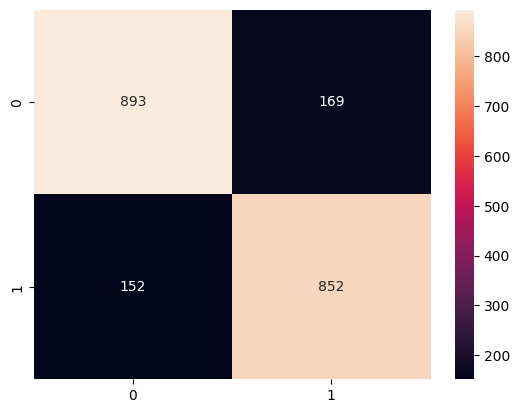

In [45]:
sns.heatmap(confusion_matrix(Y_test, y_pred), annot = True, fmt = '0.0f')

In [46]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1062
           1       0.83      0.85      0.84      1004

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066



## 10. Save the model

In [48]:
import joblib
# save the model
joblib.dump(logit_model, 'logistic_regression.pkl1')
 

['logistic_regression.pkl1']

In [50]:
# load the model
model = joblib.load('logistic_regression.pkl1')

In [51]:
print(X_test.sample(1))
model.predict(X_test.sample(1))

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
1589       0              0        0           1      62             1   

      MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
1589              1               0             0                 0  ...   

      InternetService_DSL  InternetService_Fiber optic  InternetService_No  \
1589                    0                            0                   1   

      Contract_Month-to-month  Contract_One year  Contract_Two year  \
1589                        0                  0                  1   

      PaymentMethod_Bank transfer (automatic)  \
1589                                        1   

      PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
1589                                      0                               0   

      PaymentMethod_Mailed check  
1589                           0  

[1 rows x 26 columns]


array([1])